*The complete notebook from top to bottom runs in almost ~7.5 hours due to model training and processing (especially pandas and matplotlib).* 

1. Instead, if you want to review the model evaluation, feature importance or Business Reputation Analysis, the model files and useful variables can be loaded from the "Model Loading" section directly to avoid preprocessing and model training. (It takes hardly 1 hr.)
2. And if you want to review the correlation matrix, data distribution, or retrain the model. Skip running all the cells and go to the "Feature Selection" section. Uncomment these lines to load df_full and run all the next cells directly.

### Spark Setup

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local") \
    .appName("BDPA-Project-Faizan-Working") \
    .getOrCreate()

### Reading JSONs

In [2]:
review_df = spark.read.json("yelp_academic_dataset_review.json")
business_df = spark.read.json("yelp_academic_dataset_business.json")
user_df = spark.read.json("yelp_academic_dataset_user.json")
checkin_df = spark.read.json("yelp_academic_dataset_checkin.json")
tip_df = spark.read.json("yelp_academic_dataset_tip.json")

### Reading Tables

#### Table: Review

In [3]:
review_df.printSchema()

root
 |-- business_id: string (nullable = true)
 |-- cool: long (nullable = true)
 |-- date: string (nullable = true)
 |-- funny: long (nullable = true)
 |-- review_id: string (nullable = true)
 |-- stars: double (nullable = true)
 |-- text: string (nullable = true)
 |-- useful: long (nullable = true)
 |-- user_id: string (nullable = true)



In [4]:
review_df.count()

6990280

In [5]:
review_df.show(5)

+--------------------+----+-------------------+-----+--------------------+-----+--------------------+------+--------------------+
|         business_id|cool|               date|funny|           review_id|stars|                text|useful|             user_id|
+--------------------+----+-------------------+-----+--------------------+-----+--------------------+------+--------------------+
|XQfwVwDr-v0ZS3_Cb...|   0|2018-07-07 22:09:11|    0|KU_O5udG6zpxOg-Vc...|  3.0|If you decide to ...|     0|mh_-eMZ6K5RLWhZyI...|
|7ATYjTIgM3jUlt4UM...|   1|2012-01-03 15:28:18|    0|BiTunyQ73aT9WBnpR...|  5.0|I've taken a lot ...|     1|OyoGAe7OKpv6SyGZT...|
|YjUWPpI6HXG530lwP...|   0|2014-02-05 20:30:30|    0|saUsX_uimxRlCVr67...|  3.0|Family diner. Had...|     0|8g_iMtfSiwikVnbP2...|
|kxX2SOes4o-D3ZQBk...|   1|2015-01-04 00:01:03|    0|AqPFMleE6RsU23_au...|  5.0|Wow!  Yummy, diff...|     1|_7bHUi9Uuf5__HHc_...|
|e4Vwtrqf-wpJfwesg...|   1|2017-01-14 20:54:15|    0|Sx8TMOWLNuJBWer-0...|  4.0|Cute inter

In [6]:
review_df.select('business_id','user_id','stars','date','useful','funny','cool').summary().toPandas()

,summary,business_id,user_id,stars,date,useful,funny,cool
0,count,6990280,6990280,6990280,6990280,6990280,6990280,6990280
1,mean,None,None,3.74858374771826,None,1.1846089140921394,0.32655959417934616,0.4986175088837643
2,stddev,None,None,1.4787045052556855,None,3.253766966933363,1.6887290985540495,2.1724598202111864
3,min,---kPU91CF4Lq2-WlRu9Lw,---1lKK3aKOuomHnwAkAow,1.0,2005-02-16 03:23:22,-1,-1,-1
4,25%,None,None,3.0,None,0,0,0
5,50%,None,None,4.0,None,0,0,0
6,75%,None,None,5.0,None,1,0,0
7,max,zzyx5x0Z7xXWWvWnZFuxlQ,zzzUFM4HFe0SFG0bPjntQA,5.0,2022-01-19 19:48:45,1182,792,404


>> The columns: useful, funny and cool have invalid minimum values: -1. The valid value should be 0.

#### Table: Business

In [7]:
business_df.printSchema()

root
 |-- address: string (nullable = true)
 |-- attributes: struct (nullable = true)
 |    |-- AcceptsInsurance: string (nullable = true)
 |    |-- AgesAllowed: string (nullable = true)
 |    |-- Alcohol: string (nullable = true)
 |    |-- Ambience: string (nullable = true)
 |    |-- BYOB: string (nullable = true)
 |    |-- BYOBCorkage: string (nullable = true)
 |    |-- BestNights: string (nullable = true)
 |    |-- BikeParking: string (nullable = true)
 |    |-- BusinessAcceptsBitcoin: string (nullable = true)
 |    |-- BusinessAcceptsCreditCards: string (nullable = true)
 |    |-- BusinessParking: string (nullable = true)
 |    |-- ByAppointmentOnly: string (nullable = true)
 |    |-- Caters: string (nullable = true)
 |    |-- CoatCheck: string (nullable = true)
 |    |-- Corkage: string (nullable = true)
 |    |-- DietaryRestrictions: string (nullable = true)
 |    |-- DogsAllowed: string (nullable = true)
 |    |-- DriveThru: string (nullable = true)
 |    |-- GoodForDancing: str

In [8]:
business_df.count()

150346

In [9]:
business_df.show(5)

+--------------------+--------------------+--------------------+--------------------+-------------+--------------------+-------+----------+------------+--------------------+-----------+------------+-----+-----+
|             address|          attributes|         business_id|          categories|         city|               hours|is_open|  latitude|   longitude|                name|postal_code|review_count|stars|state|
+--------------------+--------------------+--------------------+--------------------+-------------+--------------------+-------+----------+------------+--------------------+-----------+------------+-----+-----+
|1616 Chapala St, ...|{NULL, NULL, NULL...|Pns2l4eNsfO8kk83d...|Doctors, Traditio...|Santa Barbara|                NULL|      0|34.4266787|-119.7111968|Abby Rappoport, L...|      93101|           7|  5.0|   CA|
|87 Grasso Plaza S...|{NULL, NULL, NULL...|mpf3x-BjTdTEA3yCZ...|Shipping Centers,...|       Affton|{8:0-18:30, 0:0-0...|      1| 38.551126|  -90.335695|    

In [10]:
business_df.select('business_id','review_count','hours','is_open','latitude','longitude','stars','state').summary().toPandas()

,summary,business_id,review_count,is_open,latitude,longitude,stars,state
0,count,150346,150346,150346,150346,150346,150346,150346
1,mean,None,44.86656113232144,0.7961502135075094,36.6711500641456,-89.3573394897131,3.5967235576603303,None
2,stddev,None,121.12013570117027,0.4028599390900677,5.872758917014104,14.918501679930685,0.974420750920136,None
3,min,---kPU91CF4Lq2-WlRu9Lw,5,0,27.555127,-120.095137,1.0,AB
4,25%,None,8,1,32.1872778,-90.3579940828,3.0,None
5,50%,None,15,1,38.7771868,-86.1212378,3.5,None
6,75%,None,37,1,39.954044,-75.4218774,4.5,None
7,max,zzyx5x0Z7xXWWvWnZFuxlQ,7568,1,53.6791969,-73.2004570502,5.0,XMS


#### Table: User

In [11]:
user_df.printSchema()

root
 |-- average_stars: double (nullable = true)
 |-- compliment_cool: long (nullable = true)
 |-- compliment_cute: long (nullable = true)
 |-- compliment_funny: long (nullable = true)
 |-- compliment_hot: long (nullable = true)
 |-- compliment_list: long (nullable = true)
 |-- compliment_more: long (nullable = true)
 |-- compliment_note: long (nullable = true)
 |-- compliment_photos: long (nullable = true)
 |-- compliment_plain: long (nullable = true)
 |-- compliment_profile: long (nullable = true)
 |-- compliment_writer: long (nullable = true)
 |-- cool: long (nullable = true)
 |-- elite: string (nullable = true)
 |-- fans: long (nullable = true)
 |-- friends: string (nullable = true)
 |-- funny: long (nullable = true)
 |-- name: string (nullable = true)
 |-- review_count: long (nullable = true)
 |-- useful: long (nullable = true)
 |-- user_id: string (nullable = true)
 |-- yelping_since: string (nullable = true)



In [12]:
user_df.count()

1987897

In [13]:
user_df.show(5)

+-------------+---------------+---------------+----------------+--------------+---------------+---------------+---------------+-----------------+----------------+------------------+-----------------+-----+--------------------+----+--------------------+-----+------+------------+------+--------------------+-------------------+
|average_stars|compliment_cool|compliment_cute|compliment_funny|compliment_hot|compliment_list|compliment_more|compliment_note|compliment_photos|compliment_plain|compliment_profile|compliment_writer| cool|               elite|fans|             friends|funny|  name|review_count|useful|             user_id|      yelping_since|
+-------------+---------------+---------------+----------------+--------------+---------------+---------------+---------------+-----------------+----------------+------------------+-----------------+-----+--------------------+----+--------------------+-----+------+------------+------+--------------------+-------------------+
|         3.91|    

In [14]:
user_df.select('user_id','yelping_since','average_stars','review_count','cool','fans','funny','useful','compliment_cool','compliment_cute','compliment_funny','compliment_hot','compliment_list','compliment_more','compliment_note','compliment_photos','compliment_plain','compliment_profile','compliment_writer').summary().toPandas()

,summary,user_id,yelping_since,average_stars,review_count,cool,fans,funny,useful,compliment_cool,compliment_cute,compliment_funny,compliment_hot,compliment_list,compliment_more,compliment_note,compliment_photos,compliment_plain,compliment_profile,compliment_writer
0,count,1987897,1987897,1987897,1987897,1987897,1987897,1987897,1987897,1987897,1987897,1987897,1987897,1987897,1987897,1987897,1987897,1987897,1987897,1987897
1,mean,None,None,3.63049415035087,23.394409267683386,23.792913817969442,1.4657404282012598,16.970536199813168,42.29633527290398,2.8293080577112395,0.13364927860950543,2.8293080577112395,1.8070724992290847,0.06390723463036566,0.29226313033321144,1.4431346292086562,1.226859339291724,3.0118411567601338,0.17931764070271247,1.056448095650831
2,stddev,None,None,1.1833369995975145,82.56699161797889,565.3512954713351,18.13075272385579,407.8034374841018,641.4805967755902,96.66385446471259,11.356823097797161,96.66385446471259,73.60184094967366,10.04362659411937,12.824667119930178,60.16790049259038,95.1575129716489,119.38980389840354,15.155253377853501,32.17972805346817
3,min,---1lKK3aKOuomHnwAkAow,2004-10-12 08:46:11,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,25%,None,None,3.0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,50%,None,None,3.88,5,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0
6,75%,None,None,4.56,17,3,0,2,13,0,0,0,0,0,0,0,0,0,0,0
7,max,zzzUFM4HFe0SFG0bPjntQA,2022-01-19 17:15:47,5.0,17473,199878,12497,185823,206296,49967,13654,49967,25784,12669,13501,59031,82630,101097,14180,15934


#### Table: Checkin

In [15]:
checkin_df.printSchema()

root
 |-- business_id: string (nullable = true)
 |-- date: string (nullable = true)



In [16]:
checkin_df.count()

131930

In [17]:
checkin_df.show(5)

+--------------------+--------------------+
|         business_id|                date|
+--------------------+--------------------+
|---kPU91CF4Lq2-Wl...|2020-03-13 21:10:...|
|--0iUa4sNDFiZFrAd...|2010-09-13 21:43:...|
|--30_8IhuyMHbSOcN...|2013-06-14 23:29:...|
|--7PUidqRWpRSpXeb...|2011-02-15 17:12:...|
|--7jw19RH9JKXgFoh...|2014-04-21 20:42:...|
+--------------------+--------------------+
only showing top 5 rows



In [18]:
checkin_df.summary().show()

+-------+--------------------+--------------------+
|summary|         business_id|                date|
+-------+--------------------+--------------------+
|  count|              131930|              131930|
|   mean|                NULL|                NULL|
| stddev|                NULL|                NULL|
|    min|---kPU91CF4Lq2-Wl...|2009-12-30 02:53:...|
|    25%|                NULL|                NULL|
|    50%|                NULL|                NULL|
|    75%|                NULL|                NULL|
|    max|zzyx5x0Z7xXWWvWnZ...| 2022-01-19 01:15:21|
+-------+--------------------+--------------------+



#### Table: Tip

In [19]:
tip_df.printSchema()

root
 |-- business_id: string (nullable = true)
 |-- compliment_count: long (nullable = true)
 |-- date: string (nullable = true)
 |-- text: string (nullable = true)
 |-- user_id: string (nullable = true)



In [20]:
tip_df.count()

908915

In [21]:
tip_df.show(5)

+--------------------+----------------+-------------------+--------------------+--------------------+
|         business_id|compliment_count|               date|                text|             user_id|
+--------------------+----------------+-------------------+--------------------+--------------------+
|3uLgwr0qeCNMjKenH...|               0|2012-05-18 02:17:21|Avengers time wit...|AGNUgVwnZUey3gcPC...|
|QoezRbYQncpRqyrLH...|               0|2013-02-05 18:35:10|They have lots of...|NBN4MgHP9D3cw--Sn...|
|MYoRNLb5chwjQe3c_...|               0|2013-08-18 00:56:08|It's open even wh...|-copOvldyKh1qr-vz...|
|hV-bABTK-glh5wj31...|               0|2017-06-27 23:05:38|Very decent fried...|FjMQVZjSqY8syIO-5...|
|_uN0OudeJ3Zl_tf6n...|               0|2012-10-06 19:43:09|Appetizers.. plat...|ld0AperBXk1h6Ubqm...|
+--------------------+----------------+-------------------+--------------------+--------------------+
only showing top 5 rows



In [22]:
tip_df.select('business_id','user_id','compliment_count','date').summary().show()

+-------+--------------------+--------------------+--------------------+-------------------+
|summary|         business_id|             user_id|    compliment_count|               date|
+-------+--------------------+--------------------+--------------------+-------------------+
|  count|              908915|              908915|              908915|             908915|
|   mean|                NULL|                NULL|0.012524823553357574|               NULL|
| stddev|                NULL|                NULL| 0.12076339327984031|               NULL|
|    min|---kPU91CF4Lq2-Wl...|---r61b7EpVPkb4UV...|                   0|2009-04-16 13:11:49|
|    25%|                NULL|                NULL|                   0|               NULL|
|    50%|                NULL|                NULL|                   0|               NULL|
|    75%|                NULL|                NULL|                   0|               NULL|
|    max|zzyx5x0Z7xXWWvWnZ...|zzxZW6U5lCCQQeVfL...|                   

### Dataframes

In [23]:
review_df.count()

6990280

In [24]:
# converting to the Pandas dataframe just for a better readability
review_df.limit(2).toPandas()

,business_id,cool,date,funny,review_id,stars,text,useful,user_id
0,XQfwVwDr-v0ZS3_CbbE5Xw,0,2018-07-07 22:09:11,0,KU_O5udG6zpxOg-VcAEodg,3.0,"If you decide to eat here, just be aware it is...",0,mh_-eMZ6K5RLWhZyISBhwA
1,7ATYjTIgM3jUlt4UM3IypQ,1,2012-01-03 15:28:18,0,BiTunyQ73aT9WBnpR9DZGw,5.0,I've taken a lot of spin classes over the year...,1,OyoGAe7OKpv6SyGZT5g77Q


In [25]:
business_df.count()

150346

In [26]:
business_df.limit(2).toPandas()

,address,attributes,business_id,categories,city,hours,is_open,latitude,longitude,name,postal_code,review_count,stars,state
0,"1616 Chapala St, Ste 2","(None, None, None, None, None, None, None, Non...",Pns2l4eNsfO8kk83dixA6A,"Doctors, Traditional Chinese Medicine, Naturop...",Santa Barbara,None,0,34.426679,-119.711197,"Abby Rappoport, LAC, CMQ",93101,7,5.0,CA
1,87 Grasso Plaza Shopping Center,"(None, None, None, None, None, None, None, Non...",mpf3x-BjTdTEA3yCZrAYPw,"Shipping Centers, Local Services, Notaries, Ma...",Affton,"(8:0-18:30, 0:0-0:0, 8:0-14:0, None, 8:0-18:30...",1,38.551126,-90.335695,The UPS Store,63123,15,3.0,MO


In [27]:
user_df.count()

1987897

In [28]:
user_df.limit(2).toPandas()

,average_stars,compliment_cool,compliment_cute,compliment_funny,compliment_hot,compliment_list,compliment_more,compliment_note,compliment_photos,compliment_plain,...,cool,elite,fans,friends,funny,name,review_count,useful,user_id,yelping_since
0,3.91,467,56,467,250,18,65,232,180,844,...,5994,2007,267,"NSCy54eWehBJyZdG2iE84w, pe42u7DcCH2QmI81NX-8qA...",1259,Walker,585,7217,qVc8ODYU5SZjKXVBgXdI7w,2007-01-25 16:47:26
1,3.74,3131,157,3131,1145,251,264,1847,1946,7054,...,27281,"2009,2010,2011,2012,2013,2014,2015,2016,2017,2...",3138,"ueRPE0CX75ePGMqOFVj6IQ, 52oH4DrRvzzl8wh5UXyU0A...",13066,Daniel,4333,43091,j14WgRoU_-2ZE1aw1dXrJg,2009-01-25 04:35:42


In [29]:
checkin_df.count()

131930

In [30]:
checkin_df.limit(2).toPandas()

,business_id,date
0,---kPU91CF4Lq2-WlRu9Lw,"2020-03-13 21:10:56, 2020-06-02 22:18:06, 2020..."
1,--0iUa4sNDFiZFrAdIWhZQ,"2010-09-13 21:43:09, 2011-05-04 23:08:15, 2011..."


In [31]:
tip_df.count()

908915

In [32]:
tip_df.limit(2).toPandas()

,business_id,compliment_count,date,text,user_id
0,3uLgwr0qeCNMjKenHJwPGQ,0,2012-05-18 02:17:21,Avengers time with the ladies.,AGNUgVwnZUey3gcPCJ76iw
1,QoezRbYQncpRqyrLH6Iqjg,0,2013-02-05 18:35:10,They have lots of good deserts and tasty cuban...,NBN4MgHP9D3cw--SnauTkA


### Data Preprocessing

#### Data Transformation

> Converting data type of Date Column from String to Datetime

In [33]:
from pyspark.sql import functions as F

In [34]:
review_df = review_df.withColumn("date", F.to_timestamp("date"))

In [35]:
user_df.printSchema()

root
 |-- average_stars: double (nullable = true)
 |-- compliment_cool: long (nullable = true)
 |-- compliment_cute: long (nullable = true)
 |-- compliment_funny: long (nullable = true)
 |-- compliment_hot: long (nullable = true)
 |-- compliment_list: long (nullable = true)
 |-- compliment_more: long (nullable = true)
 |-- compliment_note: long (nullable = true)
 |-- compliment_photos: long (nullable = true)
 |-- compliment_plain: long (nullable = true)
 |-- compliment_profile: long (nullable = true)
 |-- compliment_writer: long (nullable = true)
 |-- cool: long (nullable = true)
 |-- elite: string (nullable = true)
 |-- fans: long (nullable = true)
 |-- friends: string (nullable = true)
 |-- funny: long (nullable = true)
 |-- name: string (nullable = true)
 |-- review_count: long (nullable = true)
 |-- useful: long (nullable = true)
 |-- user_id: string (nullable = true)
 |-- yelping_since: string (nullable = true)



In [36]:
user_df = user_df.withColumn("yelping_since", F.to_timestamp("yelping_since"))

In [37]:
user_df.printSchema()

root
 |-- average_stars: double (nullable = true)
 |-- compliment_cool: long (nullable = true)
 |-- compliment_cute: long (nullable = true)
 |-- compliment_funny: long (nullable = true)
 |-- compliment_hot: long (nullable = true)
 |-- compliment_list: long (nullable = true)
 |-- compliment_more: long (nullable = true)
 |-- compliment_note: long (nullable = true)
 |-- compliment_photos: long (nullable = true)
 |-- compliment_plain: long (nullable = true)
 |-- compliment_profile: long (nullable = true)
 |-- compliment_writer: long (nullable = true)
 |-- cool: long (nullable = true)
 |-- elite: string (nullable = true)
 |-- fans: long (nullable = true)
 |-- friends: string (nullable = true)
 |-- funny: long (nullable = true)
 |-- name: string (nullable = true)
 |-- review_count: long (nullable = true)
 |-- useful: long (nullable = true)
 |-- user_id: string (nullable = true)
 |-- yelping_since: timestamp (nullable = true)



In [38]:
tip_df = tip_df.withColumn("date", F.to_timestamp("date"))

> Transforming the column from String to Array

In [39]:
business_df = business_df.withColumn("categories", F.split(F.col("categories"), ", "))

In [40]:
business_df.printSchema()

root
 |-- address: string (nullable = true)
 |-- attributes: struct (nullable = true)
 |    |-- AcceptsInsurance: string (nullable = true)
 |    |-- AgesAllowed: string (nullable = true)
 |    |-- Alcohol: string (nullable = true)
 |    |-- Ambience: string (nullable = true)
 |    |-- BYOB: string (nullable = true)
 |    |-- BYOBCorkage: string (nullable = true)
 |    |-- BestNights: string (nullable = true)
 |    |-- BikeParking: string (nullable = true)
 |    |-- BusinessAcceptsBitcoin: string (nullable = true)
 |    |-- BusinessAcceptsCreditCards: string (nullable = true)
 |    |-- BusinessParking: string (nullable = true)
 |    |-- ByAppointmentOnly: string (nullable = true)
 |    |-- Caters: string (nullable = true)
 |    |-- CoatCheck: string (nullable = true)
 |    |-- Corkage: string (nullable = true)
 |    |-- DietaryRestrictions: string (nullable = true)
 |    |-- DogsAllowed: string (nullable = true)
 |    |-- DriveThru: string (nullable = true)
 |    |-- GoodForDancing: str

In [41]:
business_df.limit(2).toPandas()

,address,attributes,business_id,categories,city,hours,is_open,latitude,longitude,name,postal_code,review_count,stars,state
0,"1616 Chapala St, Ste 2","(None, None, None, None, None, None, None, Non...",Pns2l4eNsfO8kk83dixA6A,"[Doctors, Traditional Chinese Medicine, Naturo...",Santa Barbara,None,0,34.426679,-119.711197,"Abby Rappoport, LAC, CMQ",93101,7,5.0,CA
1,87 Grasso Plaza Shopping Center,"(None, None, None, None, None, None, None, Non...",mpf3x-BjTdTEA3yCZrAYPw,"[Shipping Centers, Local Services, Notaries, M...",Affton,"(8:0-18:30, 0:0-0:0, 8:0-14:0, None, 8:0-18:30...",1,38.551126,-90.335695,The UPS Store,63123,15,3.0,MO


In [42]:
user_df = user_df.withColumn("friends", F.split(F.col("friends"), ", "))
user_df = user_df.withColumn("elite", F.split(F.col("elite"), ", "))

In [43]:
user_df.printSchema()

root
 |-- average_stars: double (nullable = true)
 |-- compliment_cool: long (nullable = true)
 |-- compliment_cute: long (nullable = true)
 |-- compliment_funny: long (nullable = true)
 |-- compliment_hot: long (nullable = true)
 |-- compliment_list: long (nullable = true)
 |-- compliment_more: long (nullable = true)
 |-- compliment_note: long (nullable = true)
 |-- compliment_photos: long (nullable = true)
 |-- compliment_plain: long (nullable = true)
 |-- compliment_profile: long (nullable = true)
 |-- compliment_writer: long (nullable = true)
 |-- cool: long (nullable = true)
 |-- elite: array (nullable = true)
 |    |-- element: string (containsNull = false)
 |-- fans: long (nullable = true)
 |-- friends: array (nullable = true)
 |    |-- element: string (containsNull = false)
 |-- funny: long (nullable = true)
 |-- name: string (nullable = true)
 |-- review_count: long (nullable = true)
 |-- useful: long (nullable = true)
 |-- user_id: string (nullable = true)
 |-- yelping_since:

In [44]:
user_df.limit(2).toPandas()

,average_stars,compliment_cool,compliment_cute,compliment_funny,compliment_hot,compliment_list,compliment_more,compliment_note,compliment_photos,compliment_plain,...,cool,elite,fans,friends,funny,name,review_count,useful,user_id,yelping_since
0,3.91,467,56,467,250,18,65,232,180,844,...,5994,[2007],267,"[NSCy54eWehBJyZdG2iE84w, pe42u7DcCH2QmI81NX-8q...",1259,Walker,585,7217,qVc8ODYU5SZjKXVBgXdI7w,2007-01-25 16:47:26
1,3.74,3131,157,3131,1145,251,264,1847,1946,7054,...,27281,"[2009,2010,2011,2012,2013,2014,2015,2016,2017,...",3138,"[ueRPE0CX75ePGMqOFVj6IQ, 52oH4DrRvzzl8wh5UXyU0...",13066,Daniel,4333,43091,j14WgRoU_-2ZE1aw1dXrJg,2009-01-25 04:35:42


#### Data Cleaning

> Fixing the invalid values

In [45]:
cols_to_fix = ["cool", "funny", "useful"]

In [46]:
review_df.select(cols_to_fix).summary("min").show()

+-------+----+-----+------+
|summary|cool|funny|useful|
+-------+----+-----+------+
|    min|  -1|   -1|    -1|
+-------+----+-----+------+



In [47]:
for col_name in cols_to_fix:
    review_df = review_df.withColumn(
        col_name, 
        F.when(F.col(col_name) == -1, 0).otherwise(F.col(col_name))
    )

In [48]:
review_df.select(cols_to_fix).summary("min").show()

+-------+----+-----+------+
|summary|cool|funny|useful|
+-------+----+-----+------+
|    min|   0|    0|     0|
+-------+----+-----+------+



> Checking for the NULL values

In [49]:
business_df.select([
    F.count(F.when(F.col(c).isNull() | (F.col(c).cast("string") == ""), c)).alias(c) 
    for c in business_df.columns
]).toPandas()

,address,attributes,business_id,categories,city,hours,is_open,latitude,longitude,name,postal_code,review_count,stars,state
0,5127,13744,0,103,0,23223,0,0,0,0,73,0,0,0


In [50]:
business_df.count()

150346

##### NULL values will be handled this way:
- If column is unnecessary, column will be dropped
- If column is necessary and rows count is low compared to the total rows, rows will be dropped
- If column is necessary and rows count is high  compared to the total rows, values will be imputated

> Checking if any duplicate review exists

In [51]:
# Total count vs. unique count
total_count = review_df.count()
unique_count = review_df.select("review_id").distinct().count()
print(f"Total Reviews: {total_count}")
print(f"Unique Reviews: {unique_count}")

if total_count > unique_count:
    print(f"Duplicates found! {total_count - unique_count} repeated IDs.")
else:
    print("No duplicates. Every review_id is unique.")

Total Reviews: 6990280
Unique Reviews: 6990280
No duplicates. Every review_id is unique.


In [52]:
review_df.select('business_id','user_id','stars','date','useful','funny','cool').summary().toPandas()

,summary,business_id,user_id,stars,useful,funny,cool
0,count,6990280,6990280,6990280,6990280,6990280,6990280
1,mean,None,None,3.74858374771826,1.1846094863152834,0.32655988029091826,0.4986176519395503
2,stddev,None,None,1.4787045052556855,3.253766670669813,1.688728958514803,2.172459754452527
3,min,---kPU91CF4Lq2-WlRu9Lw,---1lKK3aKOuomHnwAkAow,1.0,0,0,0
4,25%,None,None,3.0,0,0,0
5,50%,None,None,4.0,0,0,0
6,75%,None,None,5.0,1,0,0
7,max,zzyx5x0Z7xXWWvWnZFuxlQ,zzzUFM4HFe0SFG0bPjntQA,5.0,1182,792,404


#### Feature Engineering

> Filling the missing values in column address by combining city and postal_code

In [53]:
business_df = business_df.withColumn(
    "address",
    F.when(
        (F.col("address").isNull()) | (F.col("address") == ""), 
        F.concat_ws(", ", F.col("postal_code"), F.col("city"))
    ).otherwise(F.col("address"))
)

In [54]:
business_df.select([
    F.count(F.when(F.col(c).isNull() | (F.col(c).cast("string") == ""), c)).alias(c) 
    for c in business_df.columns
]).toPandas()

,address,attributes,business_id,categories,city,hours,is_open,latitude,longitude,name,postal_code,review_count,stars,state
0,0,13744,0,103,0,23223,0,0,0,0,73,0,0,0


> Data Aggregation

In [55]:
checkin_df.limit(2).toPandas()

,business_id,date
0,---kPU91CF4Lq2-WlRu9Lw,"2020-03-13 21:10:56, 2020-06-02 22:18:06, 2020..."
1,--0iUa4sNDFiZFrAdIWhZQ,"2010-09-13 21:43:09, 2011-05-04 23:08:15, 2011..."


In [56]:
checkin_agg = checkin_df.withColumn(
    "checkin_count", 
    F.size(F.split(F.col("date"), ", "))
).select("business_id", "checkin_count")

In [57]:
checkin_agg.show(5)

+--------------------+-------------+
|         business_id|checkin_count|
+--------------------+-------------+
|---kPU91CF4Lq2-Wl...|           11|
|--0iUa4sNDFiZFrAd...|           10|
|--30_8IhuyMHbSOcN...|            2|
|--7PUidqRWpRSpXeb...|           10|
|--7jw19RH9JKXgFoh...|           26|
+--------------------+-------------+
only showing top 5 rows



In [58]:
business_tip_agg = tip_df.groupBy("business_id") \
    .agg(F.count("*").alias("business_tip_count"))

In [59]:
business_tip_agg.show(5)

+--------------------+------------------+
|         business_id|business_tip_count|
+--------------------+------------------+
|vxLV9tci88Hsr1G01...|               113|
|9xPOQKtIDVaI_fN3n...|                24|
|7hRaOnXRRS8q620F6...|                38|
|Ixr2-GfYKatXdq1rZ...|                 5|
|__rP5Fy4peONwyjcm...|                 5|
+--------------------+------------------+
only showing top 5 rows



In [60]:
user_tip_agg = tip_df.groupBy("user_id") \
    .agg(F.count("*").alias("user_tip_count"))

In [61]:
user_tip_agg.show(5)

+--------------------+--------------+
|             user_id|user_tip_count|
+--------------------+--------------+
|IE0f4Mt6rfEw26pn5...|             2|
|kULau64pX05OkAEmN...|             1|
|xNuunm-8T2F513gkU...|            18|
|Zsdee1KEpMwjg5cqx...|           102|
|S-gn07vdS1TqsJXWE...|            11|
+--------------------+--------------+
only showing top 5 rows



> Joining the tables

In [62]:
df = review_df \
    .join(business_df.withColumnRenamed("review_count", "business_review_count") \
                .withColumnRenamed("name", "business_name") \
                .withColumnRenamed("stars", "business_stars") \
                .withColumnRenamed("useful", "business_useful") \
                .withColumnRenamed("funny", "business_funny") \
                .withColumnRenamed("cool", "business_cool"),"business_id", "left") \
    .join(user_df.withColumnRenamed("review_count", "user_review_count") \
                .withColumnRenamed("name", "user_name") \
                .withColumnRenamed("stars", "user_stars")\
                .withColumnRenamed("useful", "user_useful") \
                .withColumnRenamed("funny", "user_funny") \
                .withColumnRenamed("cool", "user_cool"), "user_id", "left") \
    .join(checkin_agg, "business_id", "left") \
    .join(user_tip_agg, "user_id", "left") \
    .join(business_tip_agg, "business_id", "left")

> Checking NULL and NaN

In [63]:
from pyspark.sql.types import DoubleType, FloatType

# Count NULLs for all, but only NaNs for numeric columns
null_nan_counts = df.select([
    F.count(
        F.when(
            F.col(c).isNull() | 
            (F.isnan(F.col(c)) if isinstance(df.schema[c].dataType, (DoubleType, FloatType)) else F.lit(False)), 
            c
        )
    ).alias(c) 
    for c in df.columns
])

null_nan_counts.show()

+-----------+-------+----+----+-----+---------+-----+----+------+-------+----------+----------+----+------+-------+--------+---------+-------------+-----------+---------------------+--------------+-----+-------------+---------------+---------------+----------------+--------------+---------------+---------------+---------------+-----------------+----------------+------------------+-----------------+---------+-----+----+-------+----------+---------+-----------------+-----------+-------------+-------------+--------------+------------------+
|business_id|user_id|cool|date|funny|review_id|stars|text|useful|address|attributes|categories|city| hours|is_open|latitude|longitude|business_name|postal_code|business_review_count|business_stars|state|average_stars|compliment_cool|compliment_cute|compliment_funny|compliment_hot|compliment_list|compliment_more|compliment_note|compliment_photos|compliment_plain|compliment_profile|compliment_writer|user_cool|elite|fans|friends|user_funny|user_name|user_

In [64]:
# Select only columns with missing values and convert to Pandas
null_nan_counts.select(
    'attributes', 'categories', 'hours', 'average_stars', 'compliment_cool', 
    'compliment_cute', 'compliment_funny', 'compliment_hot', 'compliment_list', 
    'compliment_more', 'compliment_note', 'compliment_photos', 'compliment_plain', 
    'compliment_profile', 'compliment_writer', 'user_cool', 'elite', 'fans', 
    'friends', 'user_funny', 'user_name', 'user_review_count', 'user_useful', 
    'yelping_since', 'checkin_count', 'user_tip_count', 'business_tip_count'
).toPandas()

,attributes,categories,hours,average_stars,compliment_cool,compliment_cute,compliment_funny,compliment_hot,compliment_list,compliment_more,...,fans,friends,user_funny,user_name,user_review_count,user_useful,yelping_since,checkin_count,user_tip_count,business_tip_count
0,183723,689,398286,33,33,33,33,33,33,33,...,33,33,33,33,33,33,33,193379,4184847,492444


> Filling the NaN values

In [65]:
df = df.fillna({
    "checkin_count": 0,
    "user_tip_count": 0,
    "business_review_count": 0,
    "user_review_count": 0,
    "fans": 0,
    "text": "",
    "average_stars": 0,
    "business_stars": 0,
    "is_open": 0
})

In [66]:
df = df.withColumn(
    "categories",
    F.when(F.col("categories").isNull(), F.array().cast("array<string>"))
     .otherwise(F.col("categories"))
)

In [67]:
df.printSchema()

root
 |-- business_id: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- cool: long (nullable = true)
 |-- date: timestamp (nullable = true)
 |-- funny: long (nullable = true)
 |-- review_id: string (nullable = true)
 |-- stars: double (nullable = true)
 |-- text: string (nullable = false)
 |-- useful: long (nullable = true)
 |-- address: string (nullable = true)
 |-- attributes: struct (nullable = true)
 |    |-- AcceptsInsurance: string (nullable = true)
 |    |-- AgesAllowed: string (nullable = true)
 |    |-- Alcohol: string (nullable = true)
 |    |-- Ambience: string (nullable = true)
 |    |-- BYOB: string (nullable = true)
 |    |-- BYOBCorkage: string (nullable = true)
 |    |-- BestNights: string (nullable = true)
 |    |-- BikeParking: string (nullable = true)
 |    |-- BusinessAcceptsBitcoin: string (nullable = true)
 |    |-- BusinessAcceptsCreditCards: string (nullable = true)
 |    |-- BusinessParking: string (nullable = true)
 |    |-- ByAppointmentOn

In [68]:
df.count()

6990280

In [69]:
df.limit(2).toPandas()

,business_id,user_id,cool,date,funny,review_id,stars,text,useful,address,...,fans,friends,user_funny,user_name,user_review_count,user_useful,yelping_since,checkin_count,user_tip_count,business_tip_count
0,-KNgMklrxgRX2-T6xXeTZA,fLRkVwyKb2qQpOSGRy7B4Q,0,2018-02-01 22:18:28,0,NBn9UqKjChpvS-zS9A2QQQ,3.0,Love the pizza here. However don't try to orde...,0,710 Stewarts Ferry Pike,...,0,"[s1WDRms7FcXVSgSzhliiXQ, l2WTI_llro0WGxNl5SMd7...",0,Dee,5,0,2012-03-06 23:29:17,185,1,25
1,-99CauTgdResVER5NvRTfw,Ird9MT5P8ifqEKeJpTGUVg,0,2014-07-26 00:35:21,0,ZKAD5_Z56GhTxK4rfbgZSg,3.0,Some of the drivers are rude and disrespectful...,0,7940 Michigan Rd,...,0,"[OsWTm2KNm-7BrwQwpjEVgg, b0wLc5y1rVrEUXFKirFTd...",1,Debi,6,4,2013-09-16 12:33:58,9,0,2


> Review-based features

In [70]:
df = df.withColumn("review_length", F.length("text"))
df = df.withColumn("num_exclamations", F.size(F.split("text", "!")) - 1)
df = df.withColumn("num_caps", F.length(F.regexp_replace("text", "[^A-Z]", "")))

> Correlation heatmap between numerical features

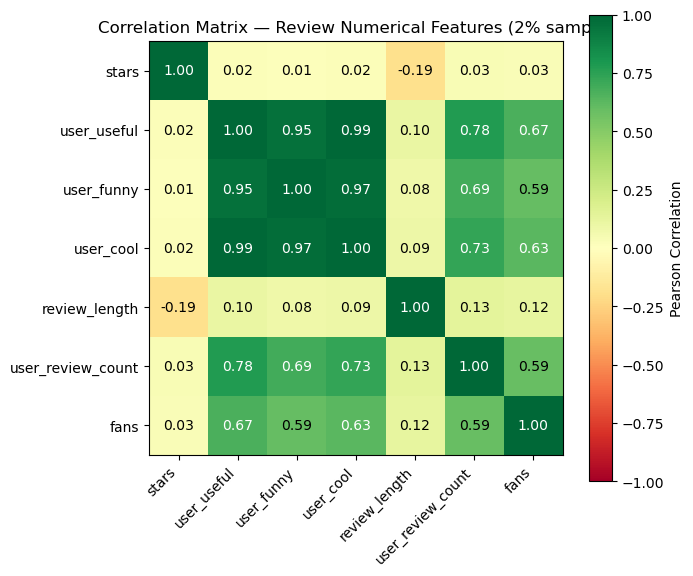

In [71]:
import pandas as pd
import matplotlib.pyplot as plt

num_cols = ["stars", "user_useful", "user_funny", "user_cool", "review_length", "user_review_count","fans"]
sample_pd = df.select(num_cols).sample(0.02, seed=42).toPandas()

corr_matrix = sample_pd.corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_matrix.values, cmap="RdYlGn", vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols))); ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha="right")
ax.set_yticklabels(num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.2f}",
                ha="center", va="center", fontsize=10,
                color="black" if abs(corr_matrix.values[i, j]) < 0.6 else "white")
plt.colorbar(im, ax=ax, label="Pearson Correlation")
ax.set_title("Correlation Matrix — Review Numerical Features (2% sample)", fontsize=12)
plt.tight_layout()
plt.show()

> User features

In [72]:
df = df.withColumn("user_activity", F.col("user_review_count") + F.col("fans"))
df = df.withColumn("user_engagement", F.col("user_useful") + F.col("user_funny") + F.col("user_cool"))

> Temporal features

In [73]:
df = df.withColumn("year", F.year("date"))
df = df.withColumn("month", F.month("date"))

> Label Encoding

In [74]:
df = df.withColumn(
    "label",
    F.when(F.col("stars") <= 2, 0)
     .when(F.col("stars") == 3, 1)
     .otherwise(2)
)

#### Feature Selection

In [75]:
df_full = df

In [78]:
df_full.write.mode("overwrite").parquet("processed_data.parquet")

> Data Reduction

In [ ]:
# If you want to review the correlation matrix, data distribution, or to retrain the model. 
# Skip running the above cells. Uncomment these lines to load df_full and run all the next cells directly. 

# df_full = spark.read.parquet("processed_data.parquet")
# df = df_full

In [76]:
df = df.select(
    "text", "label",
    "review_length", "num_exclamations", "num_caps",
    "average_stars", "user_review_count", "fans",
    "user_activity", "user_engagement",
    "business_stars","business_id",
    "business_review_count",
    "is_open", "categories", "state",
    "checkin_count", "user_tip_count",
    "year", "month"
)

In [77]:
df.limit(2).toPandas()

,text,label,review_length,num_exclamations,num_caps,average_stars,user_review_count,fans,user_activity,user_engagement,business_stars,business_id,business_review_count,is_open,categories,state,checkin_count,user_tip_count,year,month
0,The place is absolutely huge! That's the attra...,2,759,1,14,3.62,58,2,60,85,3.0,ORL4JE6tz3rJxVqkdKfegA,1639,1,"[Venues & Event Spaces, Performing Arts, Arts ...",TN,4582,0,2014,9
1,Ate dinner there tonight. Service was pretty f...,2,587,0,12,3.62,58,2,60,85,3.5,tIvfmgT1qMeAEQf8CI5fPQ,574,1,"[Bars, Nightlife, American (Traditional), Barb...",TN,627,0,2014,9


In [78]:
df.printSchema()

root
 |-- text: string (nullable = false)
 |-- label: integer (nullable = false)
 |-- review_length: integer (nullable = false)
 |-- num_exclamations: integer (nullable = false)
 |-- num_caps: integer (nullable = false)
 |-- average_stars: double (nullable = false)
 |-- user_review_count: long (nullable = false)
 |-- fans: long (nullable = false)
 |-- user_activity: long (nullable = false)
 |-- user_engagement: long (nullable = true)
 |-- business_stars: double (nullable = false)
 |-- business_id: string (nullable = true)
 |-- business_review_count: long (nullable = false)
 |-- is_open: long (nullable = false)
 |-- categories: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- state: string (nullable = true)
 |-- checkin_count: integer (nullable = false)
 |-- user_tip_count: long (nullable = false)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)



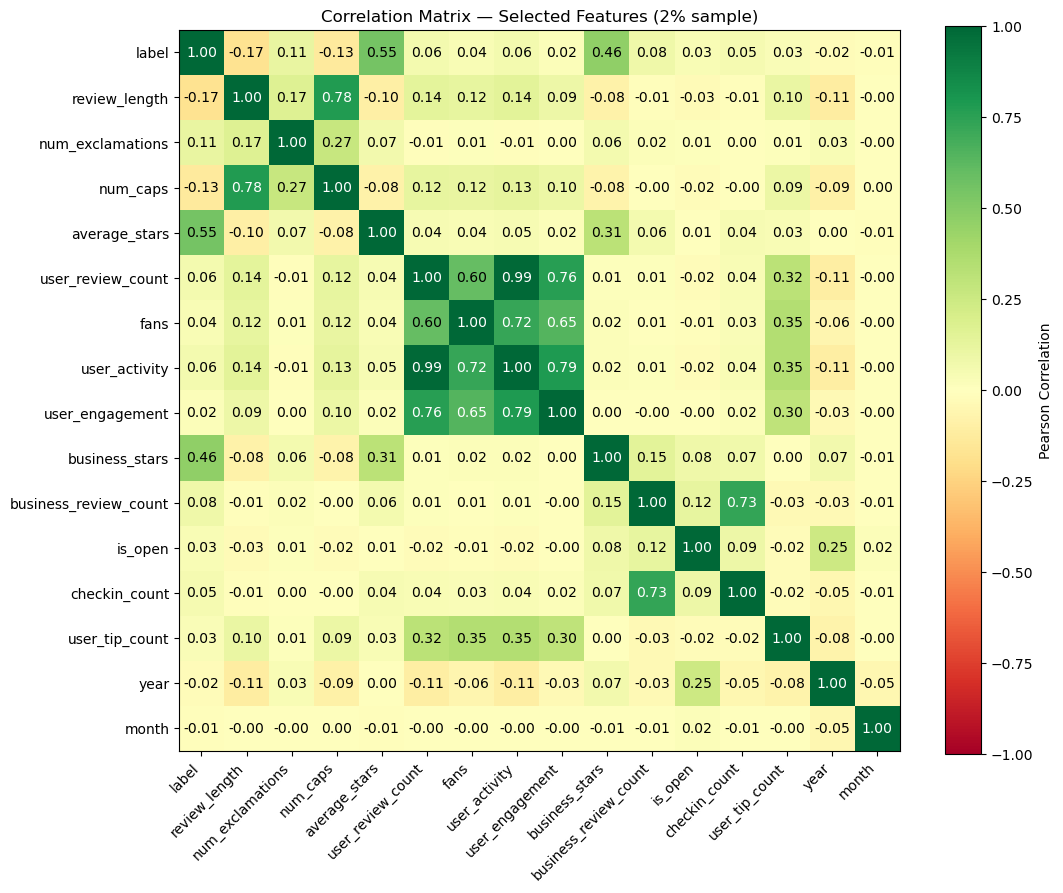

In [79]:
num_cols = ["label","review_length","num_exclamations","num_caps","average_stars","user_review_count","fans","user_activity","user_engagement","business_stars","business_review_count","is_open","checkin_count","user_tip_count","year","month"]
sample_pd = df.select(num_cols).sample(0.02, seed=42).toPandas()

corr_matrix = sample_pd.corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr_matrix.values, cmap="RdYlGn", vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols))); ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha="right")
ax.set_yticklabels(num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.2f}",
                ha="center", va="center", fontsize=10,
                color="black" if abs(corr_matrix.values[i, j]) < 0.6 else "white")
plt.colorbar(im, ax=ax, label="Pearson Correlation")
ax.set_title("Correlation Matrix — Selected Features (2% sample)", fontsize=12)
plt.tight_layout()
plt.show()

## ML Pipeline

In [80]:
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.feature import *
from pyspark.ml.classification import *
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

### Handling NULL values

In [81]:
numeric_cols = [
    "review_length", "num_exclamations", "num_caps",
    "average_stars", "user_review_count", "fans",
    "user_activity", "user_engagement",
    "business_stars", "business_review_count",
    "is_open", "checkin_count", "user_tip_count",
    "year", "month"
]

df = df.fillna(0, subset=numeric_cols)

# Fix categories NULL (VERY IMPORTANT)
df = df.withColumn(
    "categories",
    F.when(F.col("categories").isNull(), F.array().cast("array<string>"))
     .otherwise(F.col("categories"))
)

### Data Resampling

 label   count  percentage label_name
     0 1613801       23.09   Negative
     1  691934        9.90    Neutral
     2 4684545       67.02   Positive


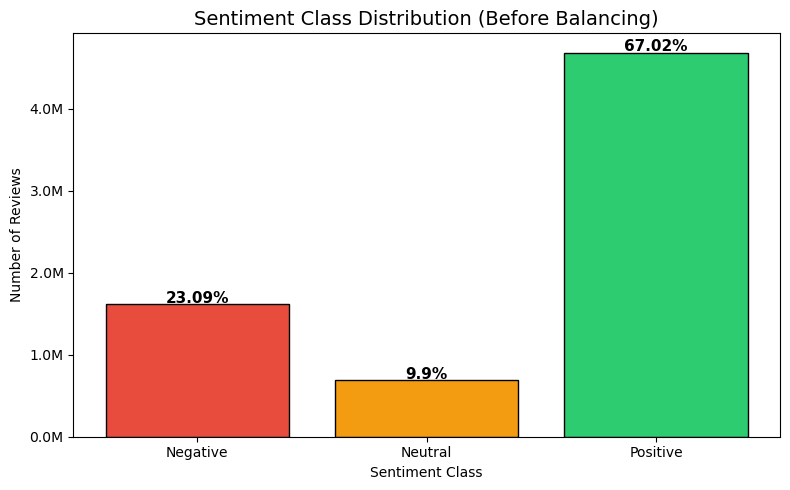

In [82]:
# ── Class distribution analysis ───────────────────────────────────────────
label_counts = df.groupBy("label").count().orderBy("label").toPandas()
total = label_counts["count"].sum()
label_counts["percentage"] = (label_counts["count"] / total * 100).round(2)
label_counts["label_name"] = label_counts["label"].map({0: "Negative", 1: "Neutral", 2: "Positive"})
print(label_counts.to_string(index=False))

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#e74c3c", "#f39c12", "#2ecc71"]
bars = ax.bar(label_counts["label_name"], label_counts["count"], color=colors, edgecolor="black")
for bar, pct in zip(bars, label_counts["percentage"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15000,
            f"{pct}%", ha="center", fontsize=11, fontweight="bold")
ax.set_title("Sentiment Class Distribution (Before Balancing)", fontsize=14)
ax.set_xlabel("Sentiment Class")
ax.set_ylabel("Number of Reviews")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.tight_layout()
plt.show()

In [83]:
# ── Stratified undersampling to fix class imbalance ──────────────────────
# Step 1: Separate classes
neg_df     = df.filter(F.col("label") == 0)
neutral_df = df.filter(F.col("label") == 1)
pos_df     = df.filter(F.col("label") == 2)

print(f"Before balancing → Negative: {neg_df.count():,}, Neutral: {neutral_df.count():,}, Positive: {pos_df.count():,}")

Before balancing → Negative: 1,613,801, Neutral: 691,934, Positive: 4,684,545


In [84]:
# Step 2: Undersample positive to match the minority class (neutral)
# We target neutral class size as the anchor
neutral_count = neutral_df.count()

# Fraction needed to downsample positive reviews
pos_fraction = min(1.0, neutral_count / pos_df.count())
neg_fraction = min(1.0, neutral_count / neg_df.count())

neg_sampled     = neg_df.sample(fraction=neg_fraction, seed=42)
neutral_sampled = neutral_df  # keep all neutral
pos_sampled     = pos_df.sample(fraction=pos_fraction, seed=42)

In [85]:
# Step 3: Combine balanced dataset
balanced_df = neg_sampled.union(neutral_sampled).union(pos_sampled)

# Verify
balanced_counts = balanced_df.groupBy("label").count().orderBy("label").toPandas()
print("\nAfter balancing:")
print(balanced_counts.to_string(index=False))


After balancing:
 label  count
     0 692619
     1 691934
     2 693296


### Data Splitting

In [86]:
# Step 4: Split into train/test AFTER balancing
train_df, test_df = balanced_df.randomSplit([0.8, 0.2], seed=25)

In [87]:
# Step 5: Apply 25% sample for memory constraints on Rahti
train_df = train_df.sample(0.25, seed=25)
test_df  = test_df.sample(0.25, seed=25)

print(f"\nTrain size: {train_df.count():,} | Test size: {test_df.count():,}")


Train size: 415,686 | Test size: 103,797


### Feature Pipeline

In [88]:
tokenizer = Tokenizer(inputCol="text", outputCol="words")
remover = StopWordsRemover(inputCol="words", outputCol="filtered")

# Reduced size → faster
text = CountVectorizer(inputCol="filtered", outputCol="rawFeatures", vocabSize=2000)
idf = IDF(inputCol="rawFeatures", outputCol="text_features", minDocFreq=5)
# minDocFreq=5: words appearing in fewer than 5 documents are almost certainly noise or typos. 

cat = CountVectorizer(inputCol="categories", outputCol="category_features", vocabSize=200, minDF=3.0)
# minDF=3.0: category tags appearing in fewer than 3 businesses are dropped.

feature_cols = [
    "text_features", "category_features",
    "review_length", "num_exclamations", "num_caps",
    "average_stars", "user_review_count", "fans",
    "user_activity", "user_engagement",
    "business_stars", "business_review_count",
    "is_open", "checkin_count", "user_tip_count",
    "year", "month"
]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features_raw",
    handleInvalid="keep"
)

scaler = StandardScaler(inputCol="features_raw", outputCol="features",
                        withMean=False)  # withMean=False for sparse vectors (TF-IDF is sparse)

feature_pipeline = Pipeline(stages=[
    tokenizer, remover, text, idf,
    cat,
    assembler, scaler
])

#### Compute class weights (For LR model)

In [89]:
# Even after undersampling, a small residual imbalance may remain.
# weightCol approach: assign each row a weight inversely proportional to class freq.

label_counts_train = train_df.groupBy("label").count().collect()
total_train = sum(r["count"] for r in label_counts_train)
n_classes = 3

class_weights = {r["label"]: total_train / (n_classes * r["count"]) for r in label_counts_train}
print("Class weights:", class_weights)

# Add weight column to both splits
from pyspark.sql.functions import when

def add_weights(sdf):
    return sdf.withColumn("classWeight",
        when(F.col("label") == 0, class_weights[0])
       .when(F.col("label") == 1, class_weights[1])
       .otherwise(class_weights[2])
    )

train_df = add_weights(train_df)
test_df  = add_weights(test_df)

Class weights: {0: 0.9995094856813099, 1: 1.0018437244680312, 2: 0.998652242538685}


### Feature Training

In [90]:
feature_model = feature_pipeline.fit(train_df)

train_featurized = feature_model.transform(train_df).cache()
test_featurized = feature_model.transform(test_df).cache()

train_featurized.count()  # force caches

416395

#### Input Size (For MLP)

In [91]:
input_size = train_featurized.select("features").first()[0].size
print("Feature size:", input_size)

Feature size: 2215


In [92]:
mlp_train = train_featurized.sample(0.25, seed=42).cache()
mlp_test  = test_featurized.sample(0.25, seed=42).cache()
print(f"MLP train size: {mlp_train.count():,} | MLP test size: {mlp_test.count():,}")

MLP train size: 104,435 | MLP test size: 26,120


#### Model Parameters

In [93]:
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    weightCol="classWeight",   # ← apply class weights
    maxIter=100,
    regParam=0.01,
    elasticNetParam=0.0
)

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=50,
    maxDepth=15,
    minInstancesPerNode=10,
    featureSubsetStrategy="sqrt"
)

mlp = MultilayerPerceptronClassifier(
    featuresCol="features",
    labelCol="label",
    layers=[input_size, 64, 3],
    maxIter=100,
    blockSize=512,
    seed=42,
    solver="l-bfgs"
)

#### Model Training

In [94]:
model_lr = lr.fit(train_featurized)

In [95]:
model_rf = rf.fit(train_featurized)

In [96]:
model_mlp = mlp.fit(mlp_train)

#### Model Saving

In [97]:
feature_model.write().overwrite().save("feature_pipeline")

model_lr.write().overwrite().save("lr_model")
model_rf.write().overwrite().save("rf_model")
model_mlp.write().overwrite().save("mlp_model")

#### Model Loading

In [80]:
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.feature import *
from pyspark.ml.classification import *
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

In [81]:
feature_model = PipelineModel.load("feature_pipeline")
lr_model = LogisticRegressionModel.load("lr_model")
rf_model = RandomForestClassificationModel.load("rf_model")
mlp_model = MultilayerPerceptronClassificationModel.load("mlp_model")
df_full = spark.read.parquet("processed_data.parquet") # For business reputation analysis at the end

#### Model Prediction

In [99]:
pred_lr = lr_model.transform(test_featurized)

In [100]:
pred_rf = rf_model.transform(test_featurized)

In [101]:
pred_mlp = mlp_model.transform(mlp_test)

### Model Evaluation

In [102]:
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

def evaluate_model(name, pred):
    acc = evaluator.evaluate(pred, {evaluator.metricName: "accuracy"})
    f1 = evaluator.evaluate(pred, {evaluator.metricName: "f1"})
    precision = evaluator.evaluate(pred, {evaluator.metricName: "weightedPrecision"})
    recall = evaluator.evaluate(pred, {evaluator.metricName: "weightedRecall"})
    
    print(f"\n{'='*40}")
    print(f" {name} — Overall Results")
    print(f"{'='*40}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")

    # Per-class breakdown
    label_map = {0.0: "Negative", 1.0: "Neutral", 2.0: "Positive"}
    pred_pd = pred.select("label", "prediction").toPandas()
    print(f"\n  Per-class Recall:")
    for label_val, label_name in label_map.items():
        class_df   = pred_pd[pred_pd["label"] == label_val]
        if len(class_df) == 0:
            continue
        correct    = (class_df["prediction"] == label_val).sum()
        class_recall = correct / len(class_df)
        print(f"    {label_name}: {class_recall:.4f} ({correct}/{len(class_df)})")

In [103]:
evaluate_model("LR", pred_lr)


 LR — Overall Results
Accuracy: 0.7817
F1 Score: 0.7815
Precision: 0.7814
Recall: 0.7817

  Per-class Recall:
    Negative: 0.8070 (28064/34774)
    Neutral: 0.6945 (24141/34758)
    Positive: 0.8440 (29063/34435)


In [104]:
evaluate_model("RF", pred_rf)


 RF — Overall Results
Accuracy: 0.6950
F1 Score: 0.6953
Precision: 0.6958
Recall: 0.6950

  Per-class Recall:
    Negative: 0.7409 (25763/34774)
    Neutral: 0.6178 (21475/34758)
    Positive: 0.7265 (25016/34435)


In [105]:
evaluate_model("MLP", pred_mlp) 


 MLP — Overall Results
Accuracy: 0.7266
F1 Score: 0.7284
Precision: 0.7369
Recall: 0.7266

  Per-class Recall:
    Negative: 0.8259 (7239/8765)
    Neutral: 0.6668 (5891/8835)
    Positive: 0.6866 (5850/8520)


In [106]:
results = []
for name, pred in [("Logistic Regression", pred_lr), ("Random Forest", pred_rf), ("MLP", pred_mlp)]:
    acc       = evaluator.evaluate(pred, {evaluator.metricName: "accuracy"})
    f1        = evaluator.evaluate(pred, {evaluator.metricName: "f1"})
    precision = evaluator.evaluate(pred, {evaluator.metricName: "weightedPrecision"})
    recall    = evaluator.evaluate(pred, {evaluator.metricName: "weightedRecall"})
    results.append({"Model": name, "Accuracy": round(acc, 4),
                    "F1": round(f1, 4), "Precision": round(precision, 4), "Recall": round(recall, 4)})

summary_df = pd.DataFrame(results)
print(summary_df.to_string(index=False))

              Model  Accuracy     F1  Precision  Recall
Logistic Regression    0.7817 0.7815     0.7814  0.7817
      Random Forest    0.6950 0.6953     0.6958  0.6950
                MLP    0.7266 0.7284     0.7369  0.7266


#### Confusion Matrix

In [107]:
def plot_confusion_matrix(pred, model_name):
    labels = [0, 1, 2]
    label_names = ["Negative", "Neutral", "Positive"]

    cm = pred.groupBy("label", "prediction").count()
    full_cm = spark.createDataFrame(
        [(l, p) for l in labels for p in labels], ["label", "prediction"]
    ).join(cm, ["label", "prediction"], "left").fillna(0)

    cm_pd = full_cm.toPandas().pivot(index="label", columns="prediction", values="count").fillna(0)

    # Normalise rows for percentage display
    cm_norm = cm_pd.div(cm_pd.sum(axis=1), axis=0).round(3) * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, data, title, fmt in zip(
        axes,
        [cm_pd, cm_norm],
        [f"{model_name} — Count", f"{model_name} — Row %"],
        [".0f", ".1f"]
    ):
        im = ax.imshow(data.values, cmap="Blues")
        ax.set_xticks(range(3)); ax.set_yticks(range(3))
        ax.set_xticklabels(label_names); ax.set_yticklabels(label_names)
        ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
        ax.set_title(title)
        for i in range(3):
            for j in range(3):
                val = data.values[i, j]
                text = f"{val:{fmt}}" + ("%" if "%" in title else "")
                ax.text(j, i, text, ha="center", va="center",
                        color="white" if val > data.values.max() * 0.5 else "black",
                        fontsize=10, fontweight="bold")
        plt.colorbar(im, ax=ax)

    plt.tight_layout()
    plt.show()

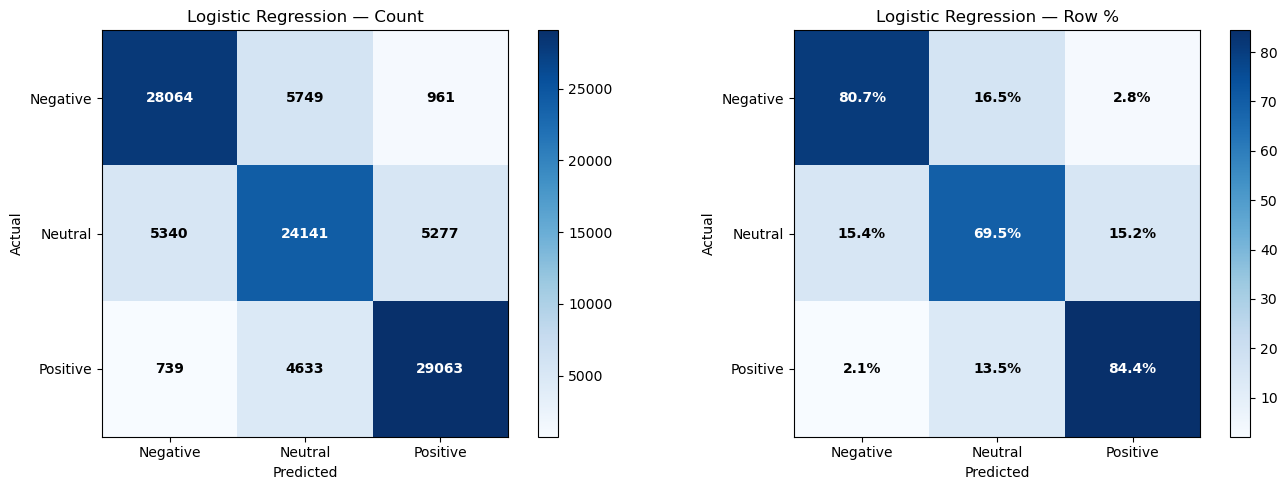

In [108]:
plot_confusion_matrix(pred_lr,  "Logistic Regression")

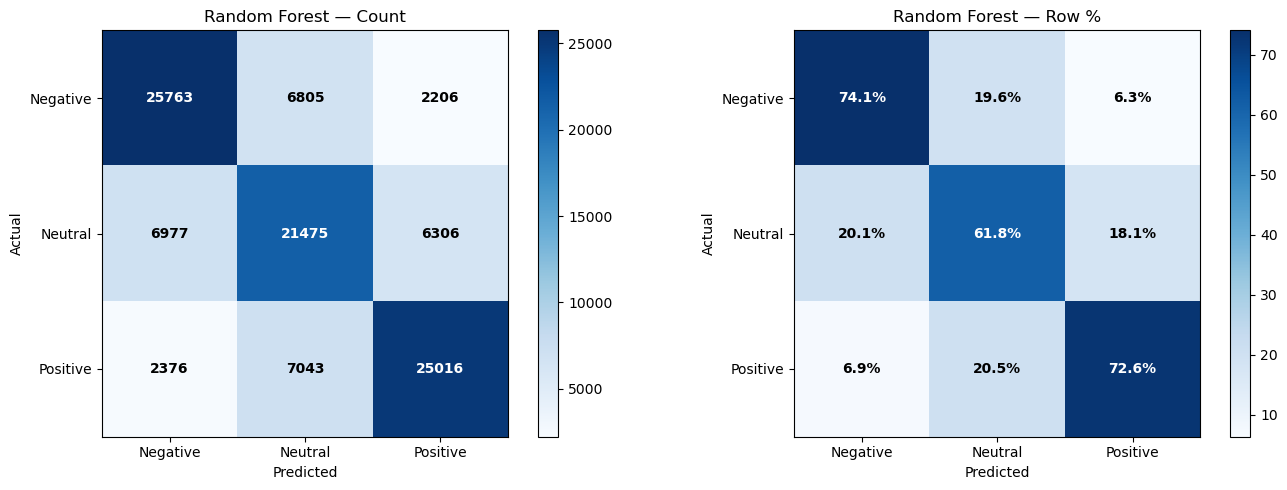

In [109]:
plot_confusion_matrix(pred_rf,  "Random Forest")

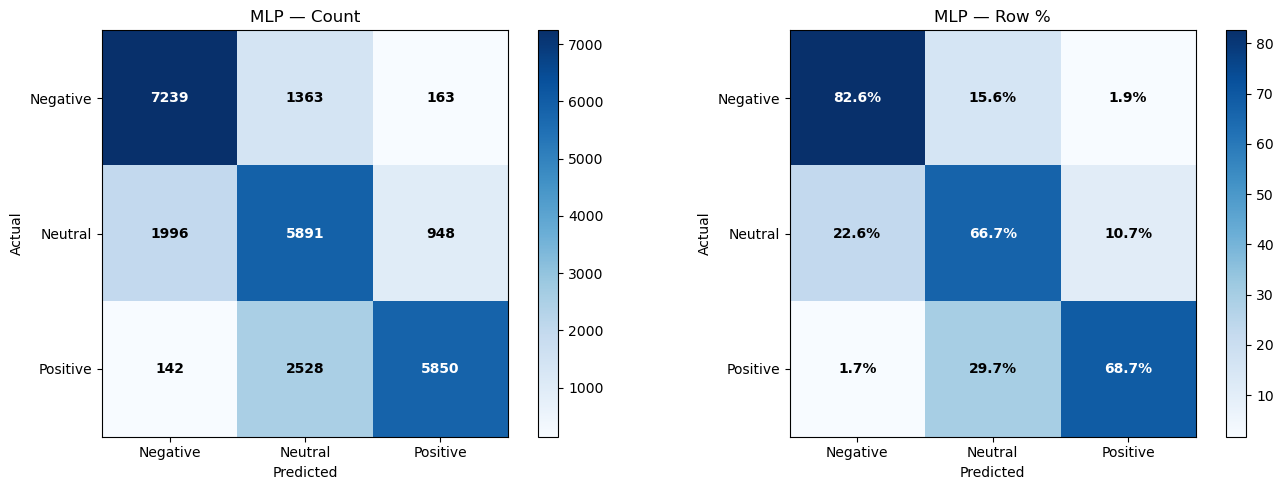

In [110]:
plot_confusion_matrix(pred_mlp, "MLP")

### Model Interpretability

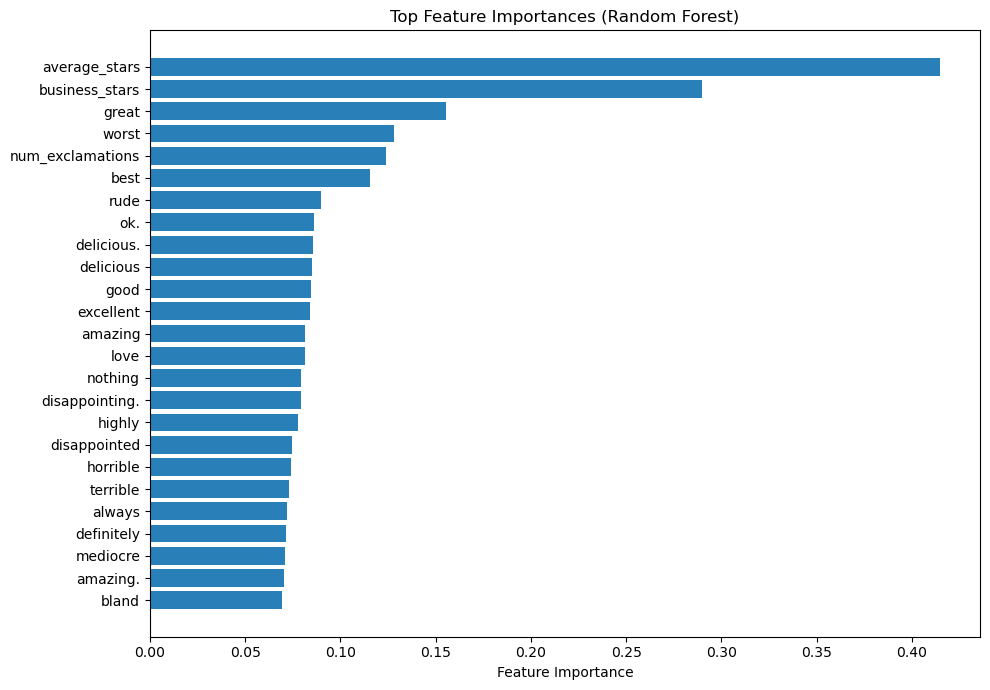


Top 15 Non-TF Features:
         feature  importance
   average_stars    0.415026
  business_stars    0.289816
           great    0.155380
           worst    0.128014
num_exclamations    0.124148
            best    0.115386
            rude    0.089794
             ok.    0.086025
      delicious.    0.085587
       delicious    0.084885
            good    0.084713
       excellent    0.084189
         amazing    0.081428
            love    0.081281
         nothing    0.079418


In [111]:
# ── RF and LR Feature Importance ─────────────────────────────────────────────────
import numpy as np

# Build feature name list (must match assembler inputCols order)
# TF-IDF → 2000 dims, CV → 200 dims, then the 15 scalar features

# Stage 2 is text_cv, Stage 4 is category cv
text_vocab = feature_model.stages[2].vocabulary
cat_vocab = feature_model.stages[4].vocabulary 

scalar_names = [
    "review_length", "num_exclamations", "num_caps",
    "average_stars", "user_review_count", "fans",
    "user_activity", "user_engagement",
    "business_stars", "business_review_count",
    "is_open", "checkin_count", "user_tip_count",
    "year", "month"
]

all_feature_names = text_vocab + cat_vocab + scalar_names

# Coefficients (weights) from the model: LR
coefficients = lr_model.coefficientMatrix.toArray()
importances = np.mean(np.abs(coefficients), axis=0)

# Coefficients (weights) from the model: RF
#importances = rf_model.featureImportances.toArray()

feat_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

# Show top 20 (skip the mostly-zero TF-IDF dims)
top_feat = feat_df[~feat_df["feature"].str.startswith("tf_")].head(30)
# Also get top 5 TF-IDF
top_tfidf = feat_df[feat_df["feature"].str.startswith("tf_")].head(5)
top_display = pd.concat([top_feat, top_tfidf]).sort_values("importance", ascending=False).head(25)

plt.figure(figsize=(10, 7))
plt.barh(top_display["feature"][::-1], top_display["importance"][::-1], color="#2980b9")
plt.xlabel("Feature Importance")
plt.title("Top Feature Importances (Logistic Regression)")
plt.tight_layout()
plt.show()

print("\nTop 15 Non-TF Features:")
print(feat_df[~feat_df["feature"].str.startswith("tf_")].head(15).to_string(index=False))

#### Features important for sentiment

In [112]:
#Extract specific rows
neg_coeffs = coefficients[0] # Coefficients for Label 0 (Negative)
pos_coeffs = coefficients[2] # Coefficients for Label 2 (Positive)

def get_top_features(weights, names, top_n=20):
    return pd.DataFrame({
        "feature": names,
        "weight": weights
    }).sort_values("weight", ascending=False).head(top_n)

# 4. Get the features
top_positive_drivers = get_top_features(pos_coeffs, all_feature_names)
top_negative_drivers = get_top_features(neg_coeffs, all_feature_names)

print("Top 10 Drivers for POSITIVE Sentiment:")
print(top_positive_drivers[["feature", "weight"]].head(10))

print("\nTop 10 Drivers for NEGATIVE Sentiment:")
print(top_negative_drivers[["feature", "weight"]].head(10))

Top 10 Drivers for POSITIVE Sentiment:
               feature    weight
2203     average_stars  0.622539
2208    business_stars  0.434723
7                great  0.233069
2201  num_exclamations  0.186222
41                best  0.173078
192          delicious  0.126929
313         delicious.  0.126485
325          excellent  0.126284
210            amazing  0.122142
48                love  0.118038

Top 10 Drivers for NEGATIVE Sentiment:
          feature    weight
264         worst  0.192021
463      horrible  0.111359
330          rude  0.109648
466      terrible  0.109589
713         waste  0.092449
439          poor  0.087974
32           told  0.087682
302  disappointed  0.083299
703         bland  0.082510
935     terrible.  0.081670


### Model Testing

In [113]:
samples_reviews = spark.createDataFrame([
    (
        "This place is absolutely amazing, loved everything!",
        51, 1, 0, # length, exclamations, caps
        4.5, 10, 2,
        12, 5,
        4.2, 100,
        1, ["None"], 0, 0, 2024, 5
    ),
    (
        "Worst experience ever. Completely disappointed.",
        47, 0, 0,
        2.0, 5, 0,
        5, 1,
        2.5, 50,
        1, ["None"], 0, 0, 2024, 5
    ),
    (
        "The food was average and the service was okay. Just an ordinary experience that was fine for the price.",
        103, 0, 0,
        3.0, 1, 0,
        1, 1,
        3.0, 20,
        1, ["None"], 0, 0, 2024, 5
    )
], [
    "text", "review_length", "num_exclamations", "num_caps",
    "average_stars", "user_review_count", "fans",
    "user_activity", "user_engagement",
    "business_stars", "business_review_count",
    "is_open", "categories",
    "checkin_count", "user_tip_count",
    "year", "month"
])

In [114]:
# Now run the combined dataframe through the pipeline
sample_features = feature_model.transform(samples_reviews)
pred = lr_model.transform(sample_features)

# Convert to Pandas and round the probabilities
results = pred.select("text", "prediction", "probability").toPandas()
results['probability'] = results['probability'].apply(lambda x: [round(float(p), 2) for p in x])

results

,text,prediction,probability
0,"This place is absolutely amazing, loved everyt...",2.0,"[0.02, 0.07, 0.91]"
1,Worst experience ever. Completely disappointed.,0.0,"[0.98, 0.02, 0.0]"
2,The food was average and the service was okay....,1.0,"[0.48, 0.5, 0.02]"


### Business Reputation Analysis

In [82]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Step 1: Score all reviews using the saved LR model ────────────────────
# df_full

# ── Step 2: Apply feature pipeline to full df ─────────────────────────────
# Use the already-fitted feature_model (trained on balanced subset)
# to transform ALL 6.99M reviews for scoring.
df_scored = feature_model.transform(df_full)

# Apply LR model to get sentiment predictions on all reviews
df_scored = lr_model.transform(df_scored)

# Extract probability of positive sentiment (class 2) as a continuous score
# This gives us a soft sentiment score [0,1] rather than a hard label,
# which is more nuanced for business reputation tracking.
from pyspark.sql.functions import udf
from pyspark.sql.types import FloatType

def safe_pos_prob(v):
    try:
        val = float(v[2])
        return None if (val != val) else val  # NaN check: NaN != NaN is True
    except:
        return None

def safe_neg_prob(v):
    try:
        val = float(v[0])
        return None if (val != val) else val
    except:
        return None

get_pos_prob = udf(safe_pos_prob, FloatType())
get_neg_prob = udf(safe_neg_prob, FloatType())

df_scored = df_scored \
    .withColumn("pos_prob", get_pos_prob(F.col("probability"))) \
    .withColumn("neg_prob", get_neg_prob(F.col("probability"))) \
    .withColumn("sentiment_score",
        F.when(
            F.col("pos_prob").isNotNull() & F.col("neg_prob").isNotNull(),
            F.col("pos_prob") - F.col("neg_prob")
        ).otherwise(None)
    )

# Verify: count NaN/null rows
null_count = df_scored.filter(F.col("sentiment_score").isNull()).count()
total_count = df_scored.count()
print(f"Rows with valid sentiment score: {total_count - null_count:,} / {total_count:,}")
print(f"NaN/null rate: {null_count/total_count*100:.2f}%")
# sentiment_score ranges from -1 (very negative) to +1 (very positive)
# This is conceptually similar to the AFINN sentiment score used in
# Guda et al. (2022) "Sentiment Analysis: Predicting Yelp Scores".

Rows with valid sentiment score: 6,990,247 / 6,990,280
NaN/null rate: 0.00%


#### Calculating Business Reputation Score

In [83]:
# ── Step 3: Business Reputation Score ─────────────────────────────────────

# nanvl converts NaN to null so that F.avg() correctly ignores them
df_scored_clean = df_scored.withColumn(
    "sentiment_score_clean",
    F.nanvl(F.col("sentiment_score"), F.lit(None).cast("float"))
)

# Aggregate per business: mean sentiment score, review volume, % positive
biz_reputation = df_scored_clean.groupBy("business_id","categories").agg(
    F.count("*").alias("total_reviews"),
    F.avg("sentiment_score").alias("avg_sentiment_score"),
    F.avg("pos_prob").alias("avg_pos_prob"),
    F.avg("neg_prob").alias("avg_neg_prob"),
    F.avg("label").alias("avg_predicted_label"),
    F.sum(F.when(F.col("prediction") == 2, 1).otherwise(0)).alias("n_positive"),
    F.sum(F.when(F.col("prediction") == 0, 1).otherwise(0)).alias("n_negative"),
    F.first("business_stars").alias("avg_stars"),
    F.first("is_open").alias("is_open"),
    F.first("state").alias("state")
).withColumn(
    "positive_pct", F.round(F.col("n_positive") / F.col("total_reviews") * 100, 1)
).withColumn(
    "negative_pct", F.round(F.col("n_negative") / F.col("total_reviews") * 100, 1)
).filter(F.col("total_reviews") >= 20)  # minimum 20 reviews for reliability

# Cache for reuse
biz_reputation = biz_reputation.cache()
valid_scores = biz_reputation.filter(F.col("avg_sentiment_score").isNotNull()).count()
total_biz = biz_reputation.count()
print(f"Businesses with ≥20 reviews: {total_biz:,}")
print(f"Businesses with valid sentiment score: {valid_scores:,}")

Businesses with ≥20 reviews: 63,489
Businesses with valid sentiment score: 63,489


#### Correlation between Sentiment Scores and Star Rating

Pearson correlation — Sentiment Score vs Actual Stars: 0.9793
Businesses used for correlation: 63,489
Businesses excluded (NaN sentiment): 0


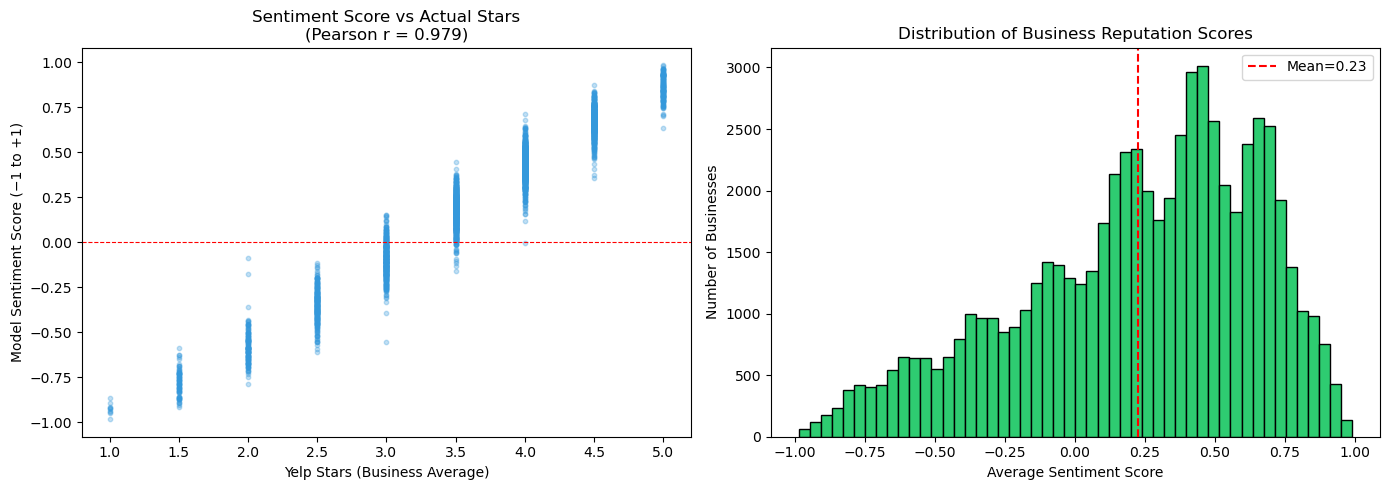

In [84]:
# ── Step 4: Sentiment Score vs Stars Correlation ───────────────────
# Key validation: Does our model's sentiment score correlate with actual stars?
# If it does, the model has learned genuine sentiment signal, not just noise.
# Guda et al. (2022) showed stars and sentiment score are highly correlated
# (r=0.52). We validate this on our model's output.

# Filter out null sentiment scores before correlation
biz_rep_valid = biz_reputation.filter(
    F.col("avg_sentiment_score").isNotNull()
)

corr_val = biz_rep_valid.select(
    F.corr("avg_sentiment_score", "avg_stars").alias("correlation")
).collect()[0]["correlation"]

print(f"Pearson correlation — Sentiment Score vs Actual Stars: {corr_val:.4f}")
print(f"Businesses used for correlation: {biz_rep_valid.count():,}")
print(f"Businesses excluded (NaN sentiment): {biz_reputation.count() - biz_rep_valid.count():,}")
# Expected: r > 0.5 confirms model validity

# Scatter plot: sentiment score vs actual stars
sample_biz = biz_rep_valid.filter(
    F.col("total_reviews").between(20, 500)
).sample(0.05, seed=42).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Sentiment Score vs Actual Stars
axes[0].scatter(sample_biz["avg_stars"], sample_biz["avg_sentiment_score"],
                alpha=0.3, s=10, color="#3498db")
axes[0].set_xlabel("Yelp Stars (Business Average)")
axes[0].set_ylabel("Model Sentiment Score (−1 to +1)")
axes[0].set_title(f"Sentiment Score vs Actual Stars\n(Pearson r = {corr_val:.3f})")
axes[0].axhline(0, color="red", linestyle="--", linewidth=0.8)

# Plot 2: Distribution of Reputation Scores
biz_pd = biz_rep_valid.select("avg_sentiment_score", "total_reviews").toPandas()
axes[1].hist(biz_pd["avg_sentiment_score"], bins=50, color="#2ecc71", edgecolor="black")
axes[1].set_xlabel("Average Sentiment Score")
axes[1].set_ylabel("Number of Businesses")
axes[1].set_title("Distribution of Business Reputation Scores")
axes[1].axvline(biz_pd["avg_sentiment_score"].mean(), color="red",
                linestyle="--", label=f"Mean={biz_pd['avg_sentiment_score'].mean():.2f}")
axes[1].legend()
plt.tight_layout()
plt.show()

#### Top Businesses by Reputation

In [85]:
# ── Step 5: Top and Bottom Businesses by Reputation ───────────────────────
# Filter to businesses with substantial review volume for reliable ranking
well_reviewed = biz_rep_valid.filter(F.col("total_reviews") >= 100)

print("\n=== TOP 10 BUSINESSES BY SENTIMENT SCORE ===")
well_reviewed.orderBy("avg_sentiment_score", ascending=False) \
    .select("business_id", "categories","total_reviews", "avg_sentiment_score",
            "positive_pct", "avg_stars") \
    .limit(10).show(truncate=True)

print("\n=== BOTTOM 10 BUSINESSES BY SENTIMENT SCORE ===")
well_reviewed.orderBy("avg_sentiment_score", ascending=True) \
    .select("business_id", "categories","total_reviews", "avg_sentiment_score",
            "negative_pct", "avg_stars") \
    .limit(10).show(truncate=True)


=== TOP 10 BUSINESSES BY SENTIMENT SCORE ===
+--------------------+--------------------+-------------+-------------------+------------+---------+
|         business_id|          categories|total_reviews|avg_sentiment_score|positive_pct|avg_stars|
+--------------------+--------------------+-------------+-------------------+------------+---------+
|ak-RiYgUZzM_90c8O...|[Professional Ser...|          178| 0.9551770849509186|        98.9|      5.0|
|-siOxQQcGKtb-04dX...|[Flowers & Gifts,...|          104| 0.9520314496297103|       100.0|      5.0|
|NDwoKO79_T49UEKVD...|[Wine Tours, Hote...|          365| 0.9450252116951224|        99.5|      5.0|
|i9n3DzCkmWDfiJ7yz...|[Real Estate, Rea...|          111| 0.9442310317142589|        99.1|      5.0|
|QNilrbTi8912ye2zt...|[Limos, Transport...|          188| 0.9387024736943397|        98.9|      5.0|
|DboqYyH-S8pV6WxaF...|[Paddleboarding, ...|          185| 0.9356635045360875|        98.9|      5.0|
|gqOmu_puGr6VY0IGR...|[Home Services, M...|  

#### Temporal Sentiment Trend

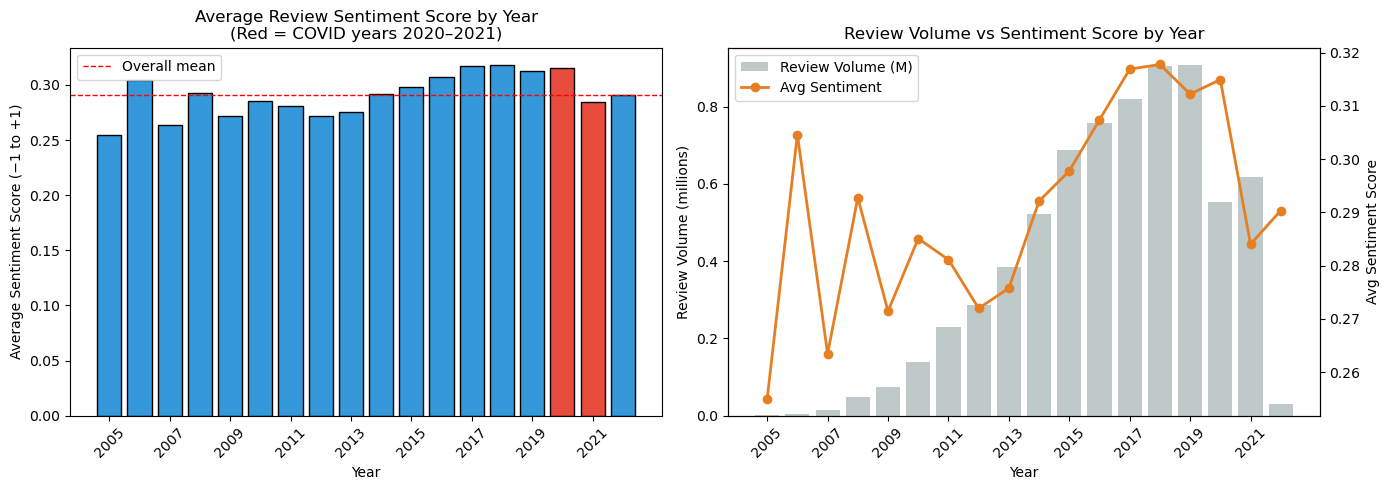

 year  review_count  avg_sentiment
 2005           854       0.254963
 2006          3853       0.304618
 2007         15363       0.263436
 2008         48226       0.292761
 2009         74387       0.271438
 2010        138587       0.285087
 2011        230813       0.281122
 2012        286570       0.271988
 2013        383950       0.275770
 2014        522275       0.292115
 2015        688415       0.297779
 2016        758882       0.307371
 2017        820048       0.316892
 2018        906362       0.317772
 2019        907284       0.312211
 2020        554557       0.314924
 2021        618189       0.284018
 2022         31632       0.290350


In [87]:
# ── Step 6: Temporal Sentiment Trend ──────────────────────────────────────
# How has overall Yelp sentiment changed year by year (2005–2022)?
# This uses the 'year' column already in df_scored.
# Motivation: Sanchez (2021) noted Yelp ratings skew positive over time.
# We test whether our model's sentiment score shows the same trend.

yearly_sentiment = df_scored_clean.filter(
    F.col("sentiment_score_clean").isNotNull() &
    F.col("year").between(2005, 2022)
).groupBy("year").agg(
    F.avg("sentiment_score_clean").alias("avg_sentiment"),
    F.count("*").alias("review_count"),
    F.avg("pos_prob").alias("avg_pos_prob")
).filter(
    F.col("review_count") >= 500  # drop years with too few reviews for reliable average
).orderBy("year").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Sentiment score trend
color_bars = ["#e74c3c" if y in [2020, 2021] else "#3498db"
              for y in yearly_sentiment["year"]]
axes[0].bar(yearly_sentiment["year"], yearly_sentiment["avg_sentiment"],
            color=color_bars, edgecolor="black")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Average Sentiment Score (−1 to +1)")
axes[0].set_title("Average Review Sentiment Score by Year\n(Red = COVID years 2020–2021)")
axes[0].axhline(yearly_sentiment["avg_sentiment"].mean(), color="red",
                linestyle="--", linewidth=1, label="Overall mean")
axes[0].legend()

# Plot 2: Review volume + sentiment dual axis
ax2 = axes[1]
color_vol = "#95a5a6"
bars = ax2.bar(yearly_sentiment["year"], yearly_sentiment["review_count"] / 1e6,
               color=color_vol, label="Review Volume (M)", alpha=0.6)
ax2.set_ylabel("Review Volume (millions)")
ax2.set_xlabel("Year")
ax_twin = ax2.twinx()
ax_twin.plot(yearly_sentiment["year"], yearly_sentiment["avg_sentiment"],
             color="#e67e22", linewidth=2, marker="o", label="Avg Sentiment")
ax_twin.set_ylabel("Avg Sentiment Score")
ax2.set_title("Review Volume vs Sentiment Score by Year")
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

for ax in [axes[0], ax2]: 
    ax.set_xticks(yearly_sentiment["year"][::2]) 
    ax.set_xticklabels(yearly_sentiment["year"][::2], rotation=45)
plt.tight_layout()
plt.show()

print(yearly_sentiment[["year", "review_count", "avg_sentiment"]].to_string(index=False))

#### State-Level Sentiment Heatmap

States/provinces with ≥5000 reviews: 14
state  review_count  avg_sentiment
   CA        348855       0.424728
   LA        761671       0.369949
   IN        489752       0.333759
   FL       1161536       0.314009
   TN        614385       0.310558
   ID        157572       0.304857
   MO        502381       0.292665
   NV        430676       0.287538
   PA       1598956       0.270774
   AZ        431704       0.266536
   AB        109436       0.223165
   NJ        260895       0.188673
   IL         51831       0.164922
   DE         70301       0.160359


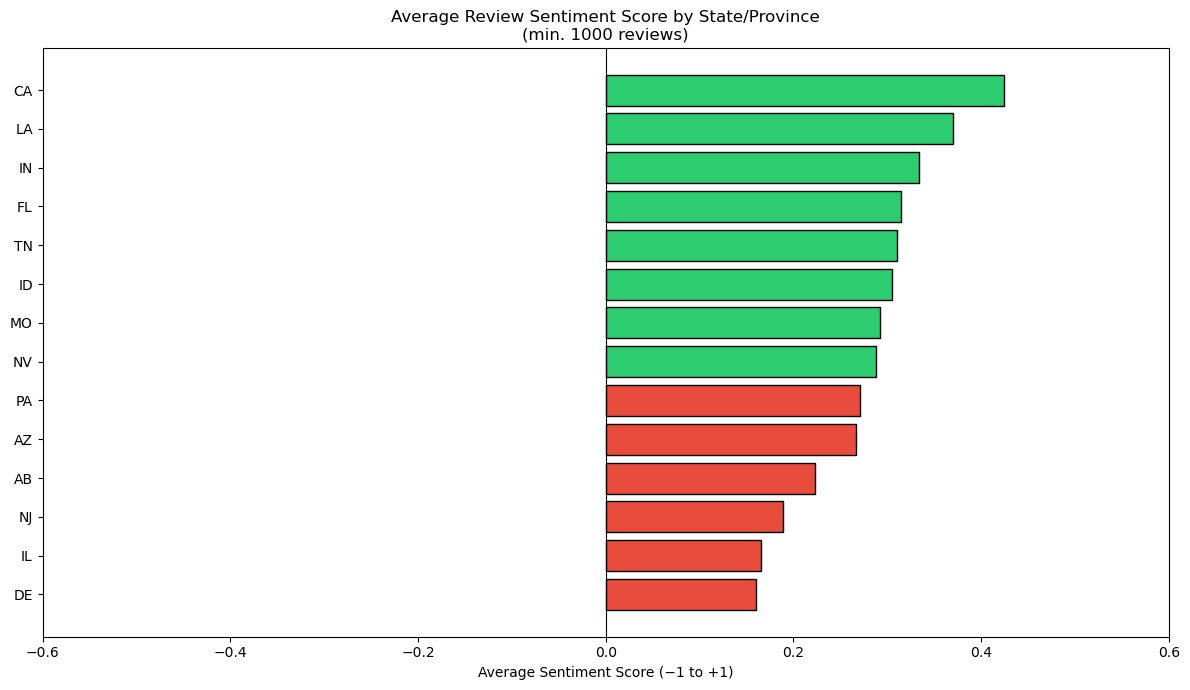

In [88]:
# ── Step 7: State-Level Sentiment Heatmap ─────────────────────────────────
# Which US states show the most positive vs negative Yelp sentiment?
# Reuses 'state' column already in df.
state_sentiment = df_scored_clean.filter(
    F.col("state").isNotNull() &
    F.col("sentiment_score_clean").isNotNull()
).groupBy("state").agg(
    F.count("*").alias("review_count"),
    F.avg("sentiment_score").alias("avg_sentiment"),
    F.avg("pos_prob").alias("pct_positive")
).filter(F.col("review_count") >= 5000).orderBy("avg_sentiment", ascending=False)

state_pd = state_sentiment.toPandas()

print(f"States/provinces with ≥5000 reviews: {len(state_pd)}")
print(state_pd[["state", "review_count", "avg_sentiment"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(12, max(6, len(state_pd) * 0.5)))
colors_state = ["#2ecc71" if s >= state_pd["avg_sentiment"].mean()
                    else "#e74c3c" for s in state_pd["avg_sentiment"]]
ax.barh(state_pd["state"][::-1], state_pd["avg_sentiment"][::-1],
        color=colors_state[::-1], edgecolor="black")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Average Sentiment Score (−1 to +1)")
ax.set_title("Average Review Sentiment Score by State/Province\n(min. 1000 reviews)")
ax.set_xlim(-0.6, 0.6)
plt.tight_layout()
plt.show()

#### Open vs Closed Business Sentiment


=== OPEN vs CLOSED BUSINESS SENTIMENT ===
 is_open  n_businesses  mean_sentiment  mean_stars  mean_positive_pct
       0         12999        0.204368    3.563890          50.581329
       1         50490        0.231920    3.632086          56.425049


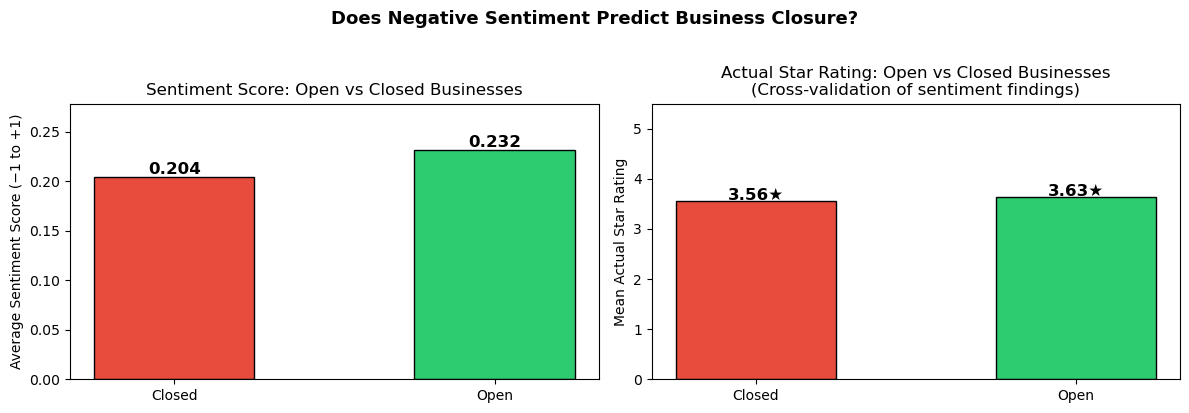

In [89]:
# ── Step 8: Open vs Closed Business Sentiment ─────────────────────────────
# Do businesses that are currently closed (is_open=0) have lower historical
# sentiment scores? This connects EDA (open/closed business analysis) to ML.
# Hypothesis: closed businesses likely accumulated more negative reviews,
# contributing to their closure.

open_closed = biz_reputation.filter(
    F.col("avg_sentiment_score").isNotNull() &
    F.col("is_open").isNotNull()
).groupBy("is_open").agg(
    F.count("*").alias("n_businesses"),
    F.avg("avg_sentiment_score").alias("mean_sentiment"),
    F.avg("avg_stars").alias("mean_stars"),
    F.avg("positive_pct").alias("mean_positive_pct")
).orderBy("is_open").toPandas()

print("\n=== OPEN vs CLOSED BUSINESS SENTIMENT ===")
print(open_closed.to_string(index=False))

if len(open_closed) == 2:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    labels_oc = ["Closed", "Open"]
    sent_vals = open_closed["mean_sentiment"].values
    star_vals = open_closed["mean_stars"].values
    colors_oc = ["#e74c3c", "#2ecc71"]

    # Plot 1: Sentiment score comparison
    bars = axes[0].bar(labels_oc, sent_vals, color=colors_oc, edgecolor="black", width=0.5)
    for bar, val in zip(bars, sent_vals):
        axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f"{val:.3f}", ha="center", fontsize=12, fontweight="bold")
    axes[0].set_ylabel("Average Sentiment Score (−1 to +1)")
    axes[0].set_title("Sentiment Score: Open vs Closed Businesses")
    axes[0].set_ylim(0, max(sent_vals) * 1.2)

    # Plot 2: Actual star rating comparison (cross-validation)
    bars2 = axes[1].bar(labels_oc, star_vals, color=colors_oc, edgecolor="black", width=0.5)
    for bar, val in zip(bars2, star_vals):
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f"{val:.2f}★", ha="center", fontsize=12, fontweight="bold")
    axes[1].set_ylabel("Mean Actual Star Rating")
    axes[1].set_title("Actual Star Rating: Open vs Closed Businesses\n(Cross-validation of sentiment findings)")
    axes[1].set_ylim(0, 5.5)

    plt.suptitle("Does Negative Sentiment Predict Business Closure?",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()